In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.style.use("default")

In [2]:
df = pd.read_csv(
    "airline-passengers.csv",
    parse_dates=["Month"],
    index_col="Month"
)

df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [3]:
print(df.info())

print("\n")

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
None


       Passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000


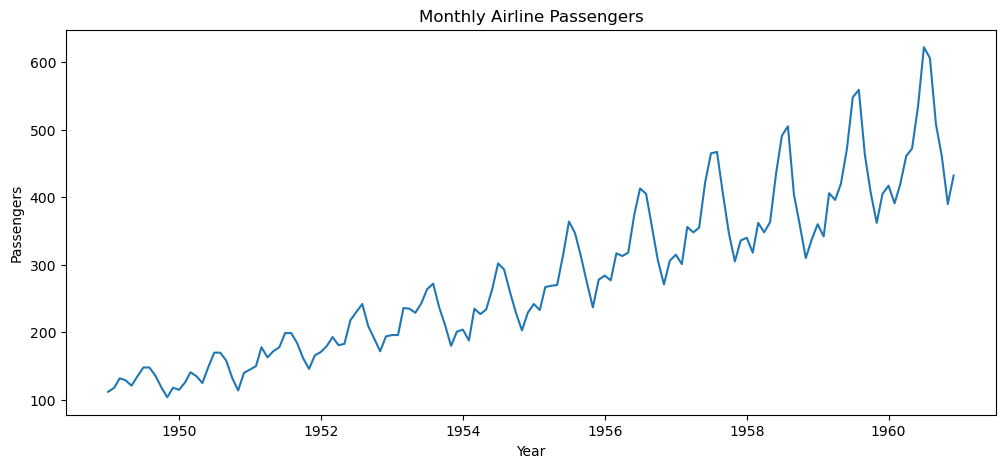

In [4]:
plt.figure(figsize=(12,5))

plt.plot(df["Passengers"])

plt.title("Monthly Airline Passengers")
plt.xlabel("Year")
plt.ylabel("Passengers")

plt.show()

In [5]:
quarterly = df.resample("Q").mean()

quarterly.head()

C:\Users\kingdom\AppData\Local\Temp\ipykernel_9360\3711841219.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly = df.resample("Q").mean()


,Passengers
Month,
1949-03-31,120.666667
1949-06-30,128.333333
1949-09-30,144.000000
1949-12-31,113.666667
1950-03-31,127.333333


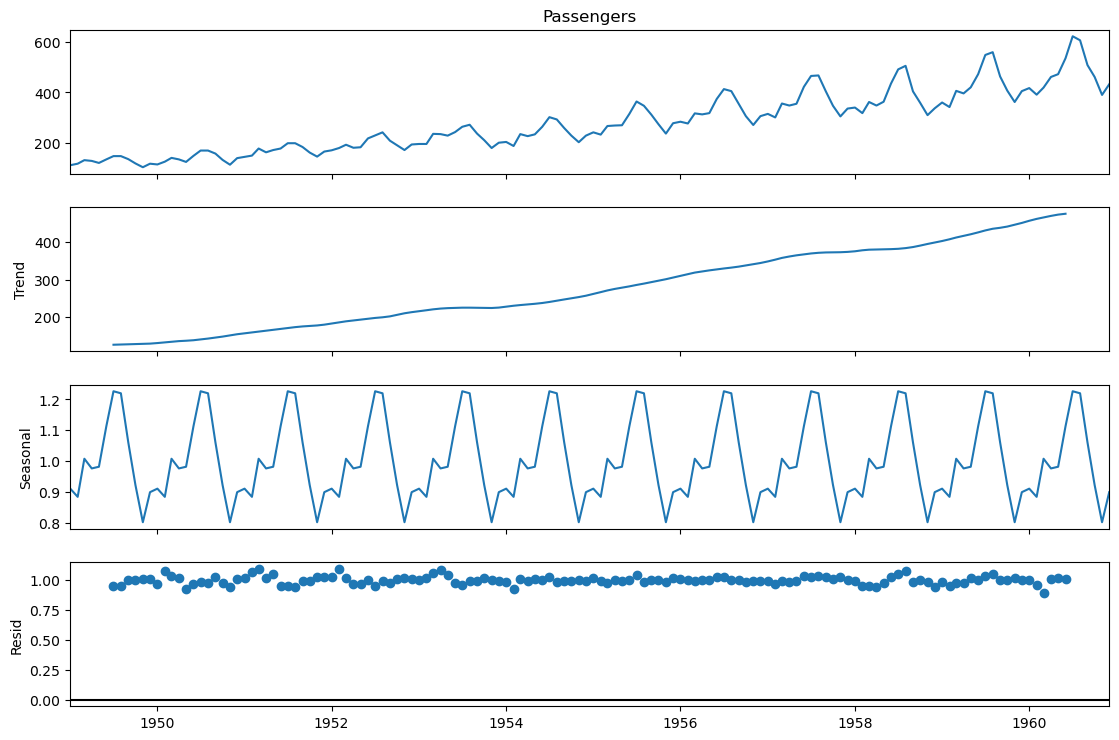

In [6]:
decomposition = seasonal_decompose(df["Passengers"], model="multiplicative", period=12)

fig = decomposition.plot()
fig.set_size_inches(12, 8)

plt.show()

In [7]:
df["MA_6"] = df["Passengers"].rolling(window=6).mean()
df["MA_12"] = df["Passengers"].rolling(window=12).mean()

df.head(15)

,Passengers,MA_6,MA_12
Month,,,
1949-01-01,112,NaN,NaN
1949-02-01,118,NaN,NaN
1949-03-01,132,NaN,NaN
1949-04-01,129,NaN,NaN
1949-05-01,121,NaN,NaN
1949-06-01,135,124.500000,NaN
1949-07-01,148,130.500000,NaN
1949-08-01,148,135.500000,NaN
1949-09-01,136,136.166667,NaN


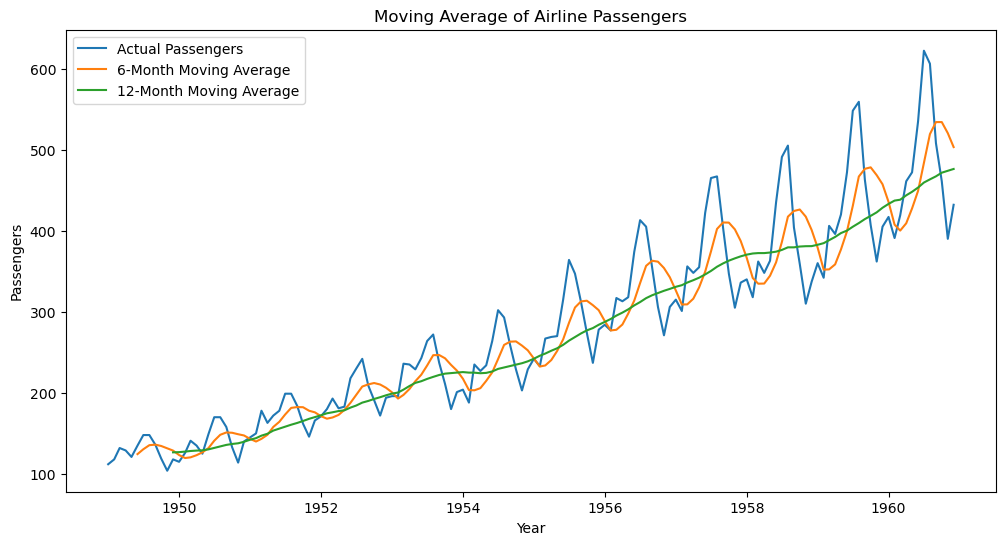

In [8]:
plt.figure(figsize=(12,6))

plt.plot(df["Passengers"], label="Actual Passengers")
plt.plot(df["MA_6"], label="6-Month Moving Average")
plt.plot(df["MA_12"], label="12-Month Moving Average")

plt.title("Moving Average of Airline Passengers")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()

plt.show()

In [9]:
train = df["Passengers"][:-12]
test = df["Passengers"][-12:]

print("Training Data:", len(train))
print("Testing Data:", len(test))

Training Data: 132
Testing Data: 12


In [10]:
model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

result = model.fit()

C:\Users\kingdom\anaconda3_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kingdom\anaconda3_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kingdom\anaconda3_new\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [11]:
forecast = result.forecast(steps=12)

forecast

1960-01-01    421.879869
1960-02-01    405.450922
1960-03-01    464.710949
1960-04-01    453.488746
1960-05-01    477.285323
1960-06-01    534.865449
1960-07-01    609.492581
1960-08-01    621.625103
1960-09-01    522.656049
1960-10-01    467.981576
1960-11-01    423.832810
1960-12-01    466.221990
Freq: MS, Name: predicted_mean, dtype: float64

In [12]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))

print("RMSE:", rmse)

RMSE: 21.186532633656032


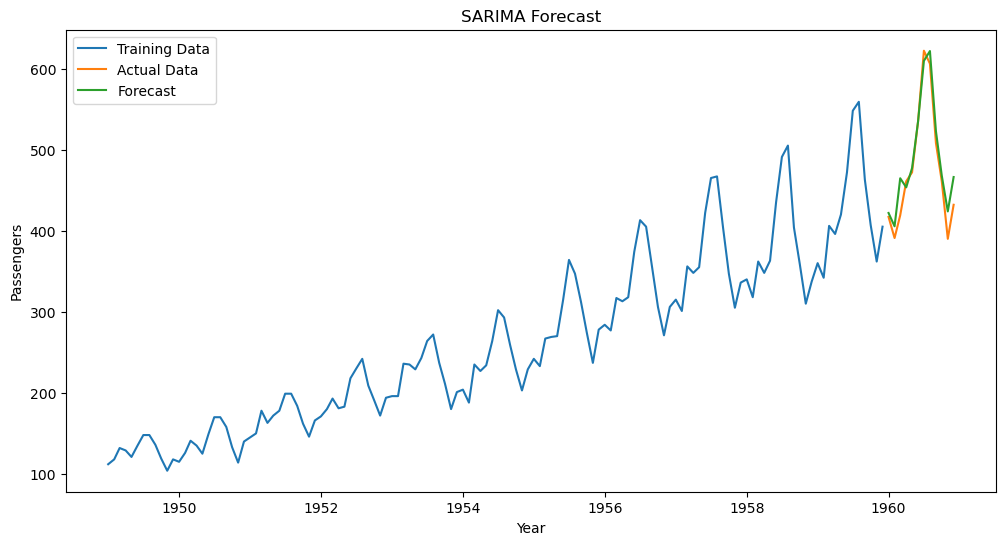

In [13]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Data")
plt.plot(test.index, forecast, label="Forecast")

plt.title("SARIMA Forecast")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()

plt.show()